In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

In [ ]:
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

# Load the dataset
df = pd.read_csv("/content/train.csv")

# Define target columns explicitly
target_cols = [
    'BlendProperty1', 'BlendProperty2', 'BlendProperty3', 'BlendProperty4', 'BlendProperty5',
    'BlendProperty6', 'BlendProperty7', 'BlendProperty8', 'BlendProperty9', 'BlendProperty10'
]

# Split features and targets
X = df.drop(target_cols, axis=1)
y = df[target_cols]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Save y_test to .npy
np.save("y_test.npy", y_test.values)


In [ ]:
target_cols = [col for col in train_df.columns if 'BlendProperty' in col]
X = train_df.drop(columns=target_cols)
y = train_df[target_cols]
test_df = test_df[X.columns]

In [ ]:
X.fillna(0, inplace=True)
test_df.fillna(0, inplace=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test_df)

In [ ]:
models = []
best_iterations = []
mae_scores = []

params = {
    'objective': 'regression',
    'metric': 'mae',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42
}

In [ ]:
lgbm_mae_scores = []
models = []

for i in range(y.shape[1]):
    print(f"Training for {y.columns[i]}")

    X_train, X_val, y_train_i, y_val_i = train_test_split(X_scaled, y.iloc[:, i], test_size=0.2, random_state=42)

    train_data = lgb.Dataset(X_train, label=y_train_i)
    val_data = lgb.Dataset(X_val, label=y_val_i)

    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[val_data],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    val_preds = model.predict(X_val)
    mae = mean_absolute_error(y_val_i, val_preds)
    lgbm_mae_scores.append(mae)

    # Optional: retrain on full data
    full_data = lgb.Dataset(X_scaled, label=y.iloc[:, i])
    final_model = lgb.train(params, full_data, num_boost_round=model.best_iteration)
    models.append(final_model)

Training for BlendProperty1
Training for BlendProperty2
Training for BlendProperty3
Training for BlendProperty4
Training for BlendProperty5
Training for BlendProperty6
Training for BlendProperty7
Training for BlendProperty8
Training for BlendProperty9
Training for BlendProperty10


In [ ]:
best_iter = model.best_iteration
best_iterations.append(best_iter)

In [ ]:
full_data = lgb.Dataset(X_scaled, label=y.iloc[:, i])
final_model = lgb.train(params, full_data, num_boost_round=best_iter)
models.append(final_model)

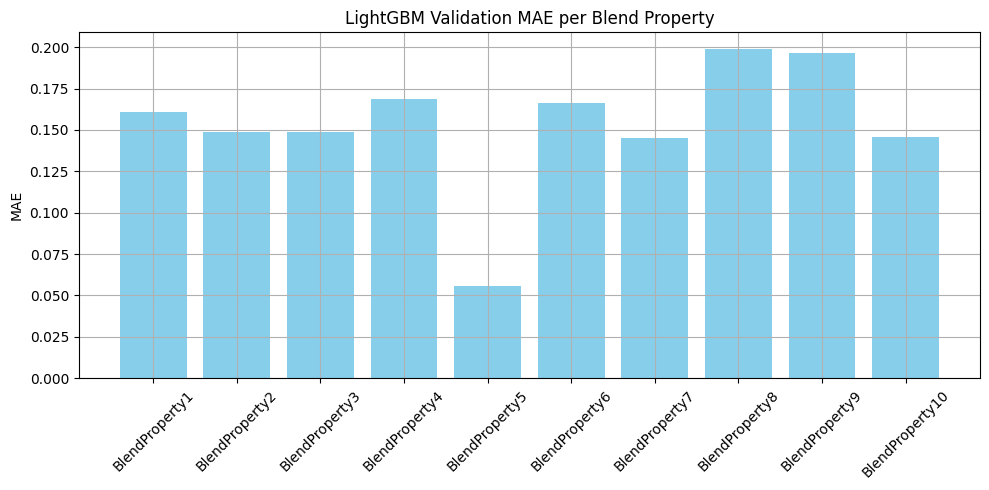

In [ ]:
import matplotlib.pyplot as plt

# Target column names (BlendProperty1 to BlendProperty10)
target_cols = y.columns.tolist()

plt.figure(figsize=(10, 5))
plt.bar(target_cols, lgbm_mae_scores, color='skyblue')
plt.ylabel("MAE")
plt.title("LightGBM Validation MAE per Blend Property")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


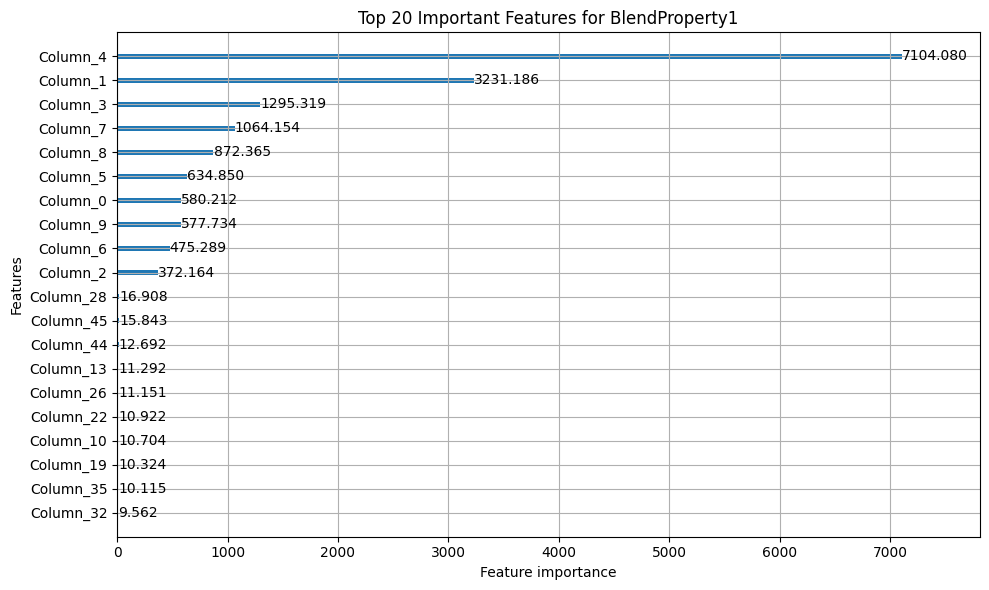

In [ ]:
lgb.plot_importance(models[0], max_num_features=20, importance_type='gain', figsize=(10, 6))
plt.title(f"Top 20 Important Features for {target_cols[0]}")
plt.tight_layout()
plt.show()

In [ ]:
lgbm_models = []
lgbm_mae_scores = []

for i in range(y.shape[1]):
    ...
    lgbm_models.append(final_model)


In [ ]:
lgbm_preds = np.column_stack([model.predict(test_scaled) for model in lgbm_models])
np.save("lgbm_preds.npy", lgbm_preds)  # Save LightGBM predictions


In [ ]:
test_predictions = np.zeros((len(test_scaled), len(lgbm_models)))

for i, model in enumerate(lgbm_models):
    test_predictions[:, i] = model.predict(test_scaled)

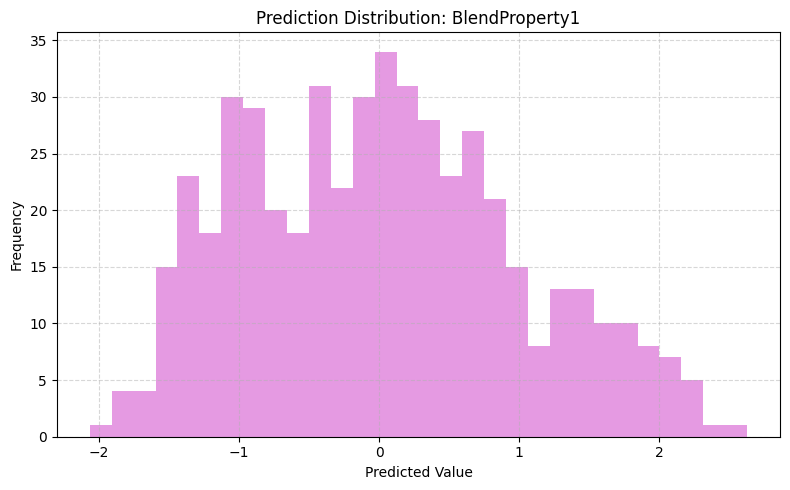

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(test_predictions[:, 0], bins=30, color='orchid', alpha=0.7)
plt.title(f"Prediction Distribution: {target_cols[0]}")
plt.xlabel("Predicted Value")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
submission = pd.DataFrame(test_predictions, columns=target_cols)
submission.insert(0, 'ID', range(1, len(test_df) + 1))
submission.to_csv("submission.csv", index=False)
print("✅ Submission saved: submission.csv")

✅ Submission saved: submission.csv
